In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/content/test.csv')
df
df.dtypes
df.isna().sum()


,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


In [9]:
df=df.drop(columns=['Unnamed: 0','id'])

KeyError: "['Unnamed: 0', 'id'] not found in axis"

In [11]:
df['Arrival Delay in Minutes']=df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

In [12]:
df.isna().sum().sum()

np.int64(0)

In [13]:
# 1) which travel class has the most passengers?
df1 = df.groupby('Class')['Class'].count().sort_values(ascending=False)
df1

,Class
Class,
Business,12495
Eco,11564
Eco Plus,1917


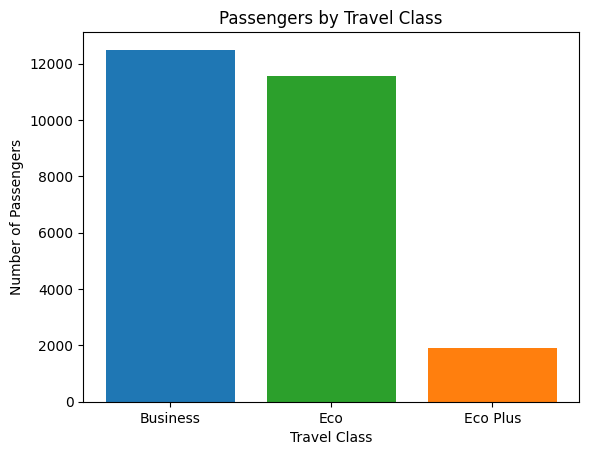

In [14]:
# plotting bar plot
bar_color = ['tab:blue', 'tab:green', 'tab:orange']
plt.bar(df1.index, df1.values, color=bar_color)
plt.xlabel('Travel Class')
plt.ylabel('Number of Passengers')
plt.title('Passengers by Travel Class')
plt.show()

In [15]:
# 2) what are the top 5 highest rated services?
services = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
            'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
            'Inflight entertainment', 'On-board service', 'Leg room service',
            'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']
df2 = df[services].mean().sort_values(ascending=False).head(5)
df2

,0
Inflight service,3.649253
Baggage handling,3.633238
Seat comfort,3.449222
On-board service,3.385664
Inflight entertainment,3.357753


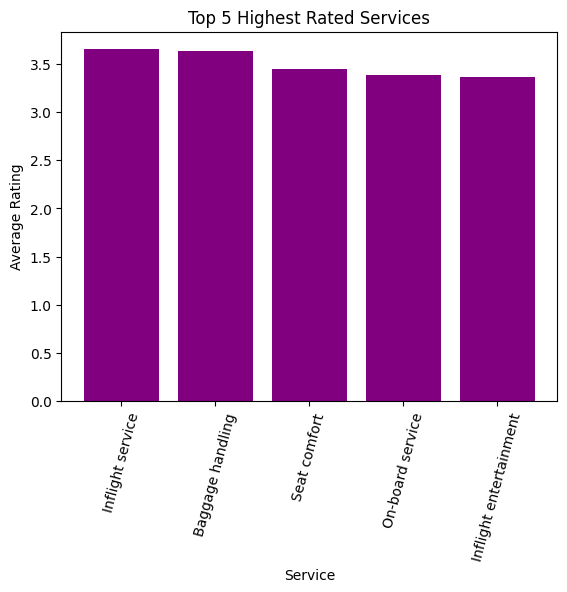

In [16]:
plt.bar(df2.index, df2.values, color='purple')
plt.xlabel('Service')
plt.ylabel('Average Rating')
plt.xticks(rotation=75)
plt.title('Top 5 Highest Rated Services')
plt.show()

In [17]:
# creating age groups and a numeric satisfied column
df['age_group'] = pd.cut(df['Age'], bins=[0, 20, 30, 40, 50, 60, 100],
                         labels=['<=20', '21-30', '31-40', '41-50', '51-60', '60+'])
df['satisfied_flag'] = (df['satisfaction'] == 'satisfied').astype(int)

In [20]:
# 3) how does the satisfaction rate change across age groups?
sat_rate = df.groupby('age_group', observed=True)['satisfied_flag'].mean() * 100
sat_rate

,satisfied_flag
age_group,
<=20,21.247706
21-30,37.254539
31-40,43.823473
41-50,57.637334
51-60,57.773593
60+,20.741097


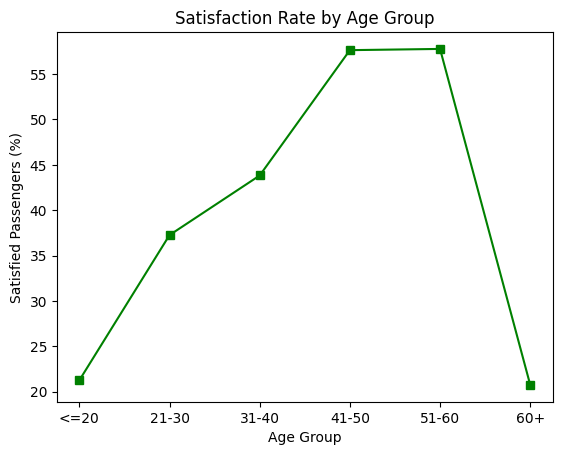

In [21]:
# plotting line chart
plt.plot(sat_rate.index, sat_rate.values, color='g', marker='s')
plt.xlabel('Age Group')
plt.ylabel('Satisfied Passengers (%)')
plt.title('Satisfaction Rate by Age Group')
plt.show()

In [22]:
# 4) what is the average flight distance for each age group?
distance = df.groupby('age_group', observed=True)['Flight Distance'].mean()
distance

,Flight Distance
age_group,
<=20,926.731743
21-30,1042.041126
31-40,1201.678743
41-50,1375.862063
51-60,1395.909186
60+,944.838787


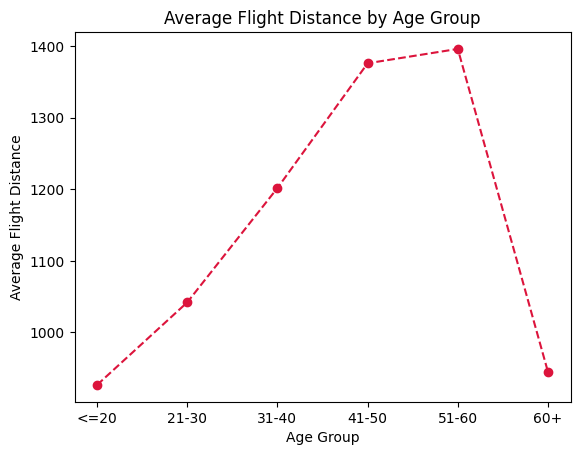

In [23]:
plt.plot(distance.index, distance.values, linestyle='--', color='crimson', marker='o')
plt.xlabel('Age Group')
plt.ylabel('Average Flight Distance')
plt.title('Average Flight Distance by Age Group')
plt.show()

In [25]:
# 5) what is the share of satisfied and not satisfied passengers?
df5 = df.groupby('satisfaction')['satisfaction'].count()
df5

,satisfaction
satisfaction,
neutral or dissatisfied,14573
satisfied,11403


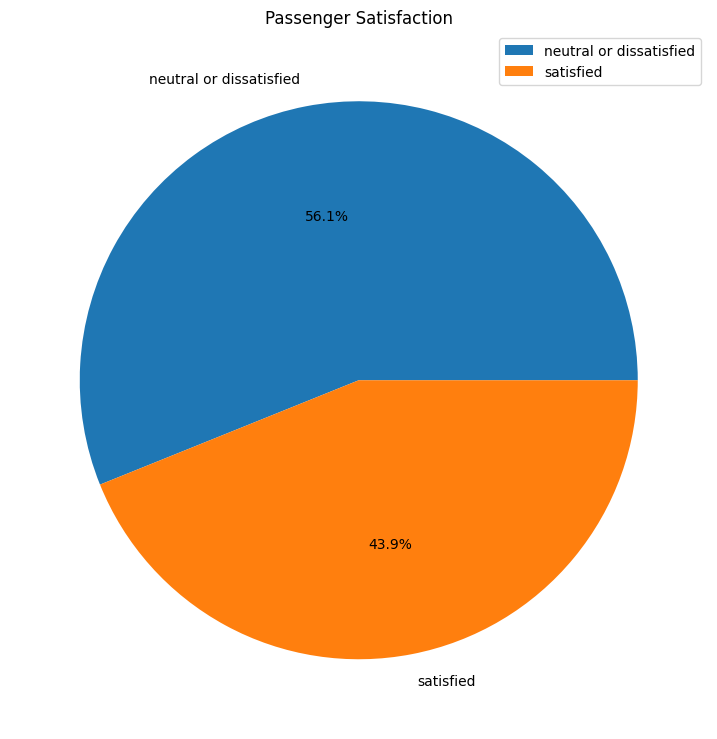

In [26]:
# plotting pie chart
plt.figure(figsize=(9, 10))
plt.pie(df5.values, labels=df5.index, autopct='%1.1f%%')
plt.title('Passenger Satisfaction')
plt.legend(loc='upper right')
plt.show()

In [27]:
# 6) what is the split of loyal and disloyal customers?
df6 = df.groupby('Customer Type')['Customer Type'].count()
df6

,Customer Type
Customer Type,
Loyal Customer,21177
disloyal Customer,4799


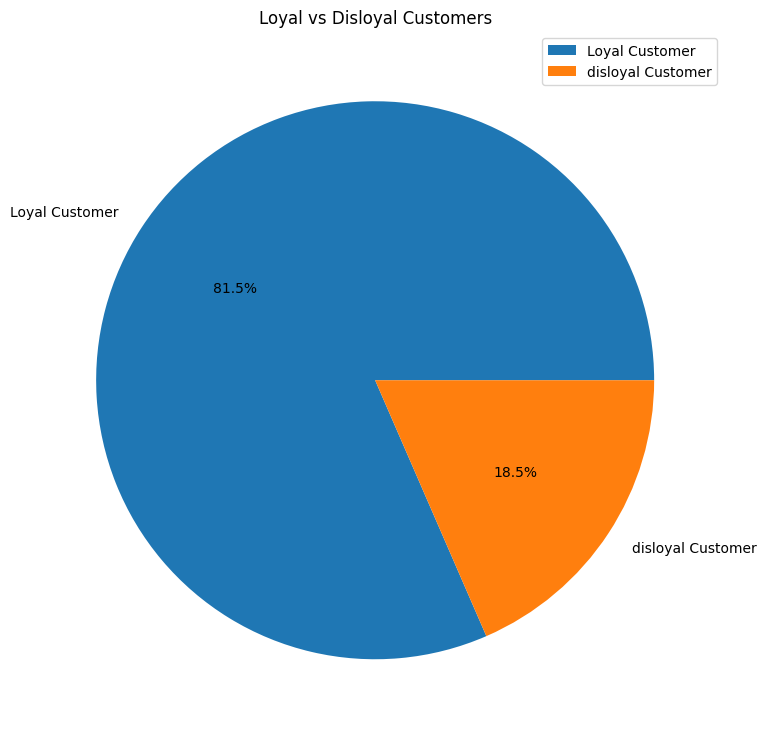

In [28]:
plt.figure(figsize=(9, 10))
plt.pie(df6.values, labels=df6.index, autopct='%1.1f%%')
plt.title('Loyal vs Disloyal Customers')
plt.legend(loc='upper right')
plt.show()

In [29]:
# 7) which are the 3 lowest rated services?
low_services = df[services].mean().sort_values().head(3)
low_services

,0
Inflight wifi service,2.724746
Ease of Online booking,2.756775
Gate location,2.977094


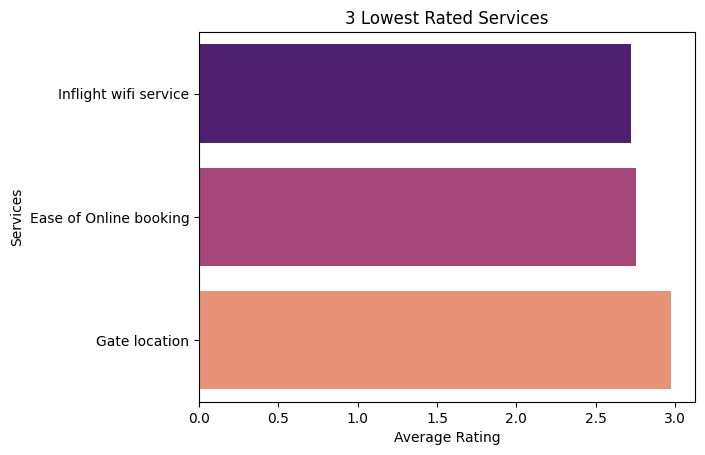

In [30]:
sns.barplot(x=low_services.values, y=low_services.index, palette='magma', hue=low_services.index)
plt.xlabel('Average Rating')
plt.ylabel('Services')
plt.title('3 Lowest Rated Services')
plt.show()

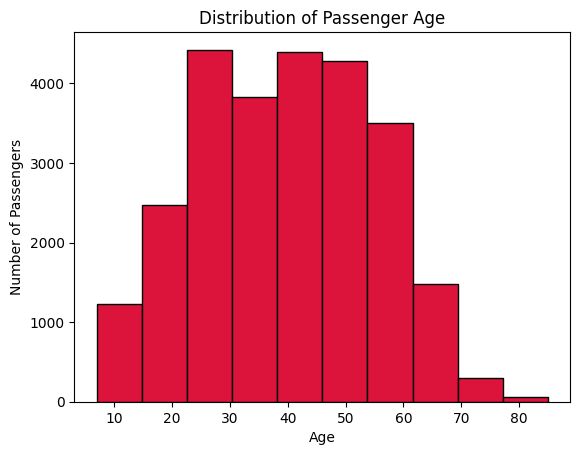

In [31]:
# 8) what is the age distribution of passengers?
plt.hist(df['Age'], bins=10, edgecolor='black', color='crimson')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Distribution of Passenger Age')
plt.show()

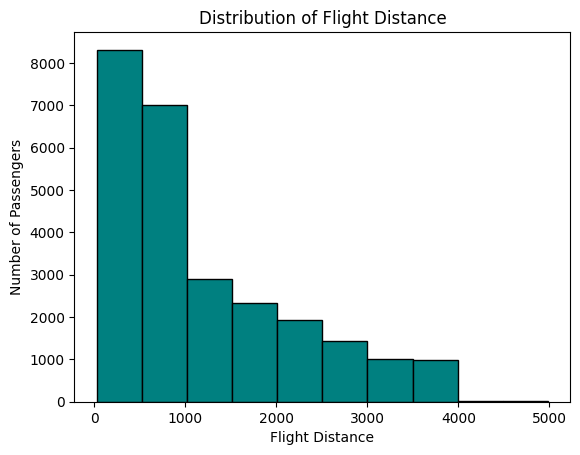

In [32]:
# 9) what is the distribution of flight distance?
plt.hist(df['Flight Distance'], bins=10, edgecolor='black', color='teal')
plt.xlabel('Flight Distance')
plt.ylabel('Number of Passengers')
plt.title('Distribution of Flight Distance')
plt.show()

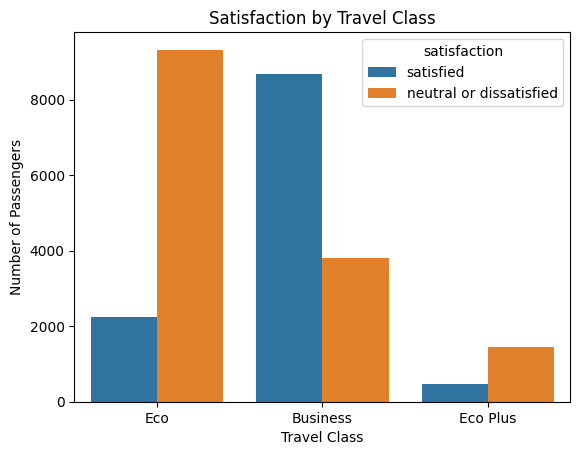

In [33]:
# 1) how does satisfaction differ across travel classes?
sns.countplot(x='Class', hue='satisfaction', data=df)
plt.xlabel('Travel Class')
plt.ylabel('Number of Passengers')
plt.title('Satisfaction by Travel Class')
plt.show()


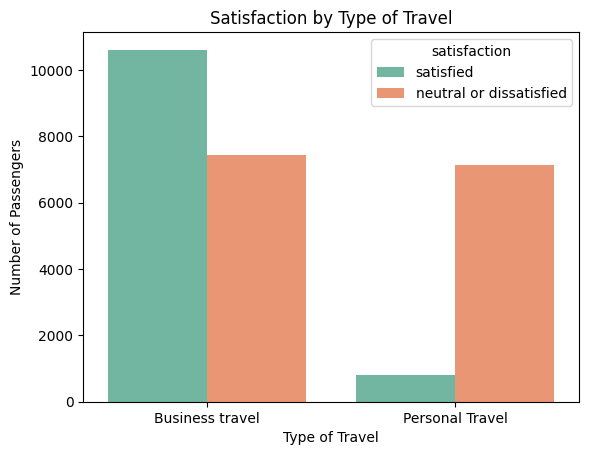

In [34]:
# 2) how does satisfaction differ by type of travel?
sns.countplot(x='Type of Travel', hue='satisfaction', data=df, palette='Set2')
plt.xlabel('Type of Travel')
plt.ylabel('Number of Passengers')
plt.title('Satisfaction by Type of Travel')
plt.show()

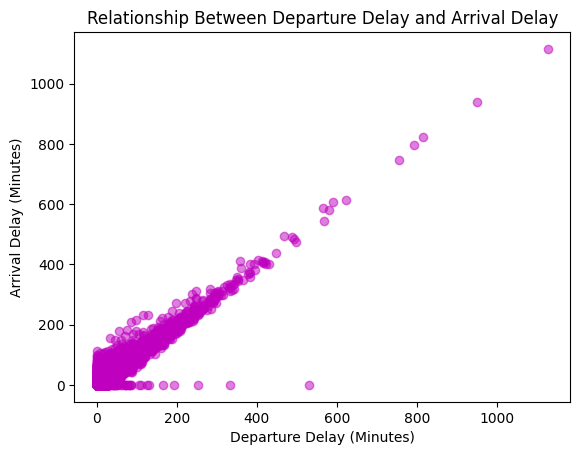

In [35]:
# 10) is there a relationship between departure delay and arrival delay?
plt.scatter(df['Departure Delay in Minutes'], df['Arrival Delay in Minutes'], color='m', alpha=0.5)
plt.xlabel('Departure Delay (Minutes)')
plt.ylabel('Arrival Delay (Minutes)')
plt.title('Relationship Between Departure Delay and Arrival Delay')
plt.show()

In [38]:
# 11) what is the relationship between online boarding rating and satisfaction?
correlation = df['Online boarding'].corr(df['satisfied_flag'])
print(correlation)

0.49452624419860497


                        Online boarding  Inflight entertainment  Seat comfort  \
Online boarding                1.000000                0.279391      0.415414   
Inflight entertainment         0.279391                1.000000      0.616817   
Seat comfort                   0.415414                0.616817      1.000000   
Inflight wifi service          0.459366                0.201782      0.116991   
Leg room service               0.120354                0.303203      0.099150   
satisfied_flag                 0.494526                0.398951      0.346275   

                        Inflight wifi service  Leg room service  \
Online boarding                      0.459366          0.120354   
Inflight entertainment               0.201782          0.303203   
Seat comfort                         0.116991          0.099150   
Inflight wifi service                1.000000          0.159699   
Leg room service                     0.159699          1.000000   
satisfied_flag                

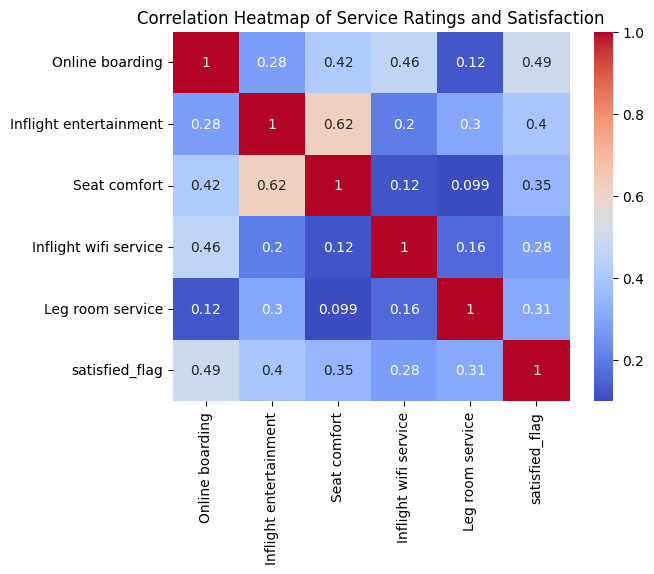

In [39]:
# 12) how are the service ratings correlated with satisfaction?
cols = ['Online boarding', 'Inflight entertainment', 'Seat comfort',
        'Inflight wifi service', 'Leg room service', 'satisfied_flag']
c = df[cols].corr()
print(c)
sns.heatmap(c, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Service Ratings and Satisfaction')
plt.show()

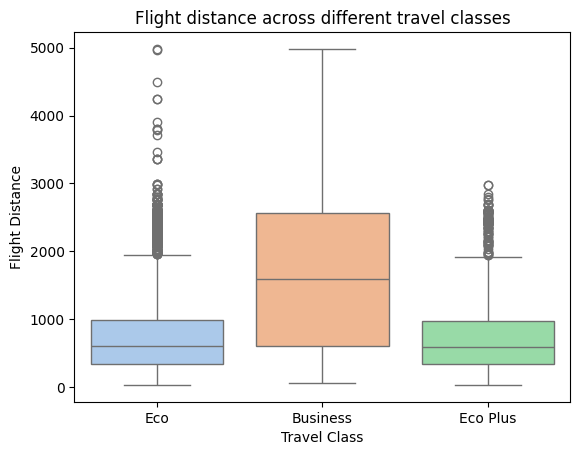

In [40]:
# 13) how does flight distance vary across different travel classes?
sns.boxplot(data=df, x='Class', y='Flight Distance',
            palette='pastel', hue='Class')
plt.title('Flight distance across different travel classes')
plt.xlabel('Travel Class')
plt.ylabel('Flight Distance')
plt.show()

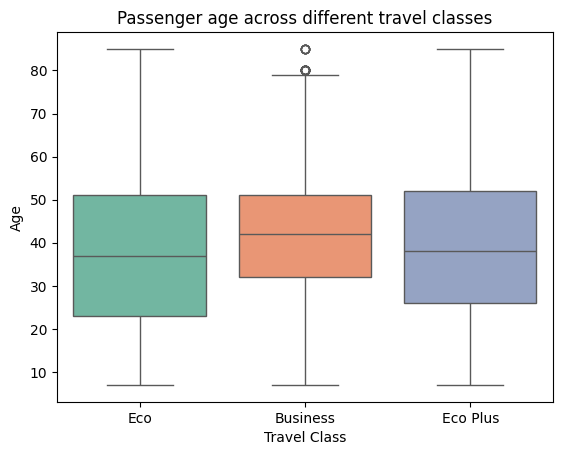

In [41]:
# 2) how does passenger age vary across different travel classes?
sns.boxplot(data=df, x='Class', y='Age',
            palette='Set2', hue='Class')
plt.title('Passenger age across different travel classes')
plt.xlabel('Travel Class')
plt.ylabel('Age')
plt.show()